# NAc Syllable and Bout DA Summary

This notebook focuses on NAc (`n*` subjects) and asks two questions:

1. Do different syllables/states show different average DA values?
2. Do different bout phases show different average DA values?

For inference-style summaries, the notebook uses subject-bout means so long bouts do not dominate the results.

In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_style("white")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Keypoint_moseq_analysis":
    ANALYSIS_DIR = PROJECT_ROOT
    REPO_ROOT = PROJECT_ROOT.parent
elif (PROJECT_ROOT / "Keypoint_moseq_analysis").exists():
    REPO_ROOT = PROJECT_ROOT
    ANALYSIS_DIR = PROJECT_ROOT / "Keypoint_moseq_analysis"
else:
    ANALYSIS_DIR = PROJECT_ROOT
    REPO_ROOT = PROJECT_ROOT.parent

POSE_TRACKING_DIR = REPO_ROOT / "Pose_Tracking"

PROJECT_DIR = ANALYSIS_DIR / "keypoint_moseq_project_home_cage"
MODEL_NAME = "2026_05_13-23_29_52"
SYLLABLE_FRAMES_PATH = PROJECT_DIR / MODEL_NAME / "syllable_frames.csv"
DA_PATH = POSE_TRACKING_DIR / "HC_automated_social_behaviors.csv"

BEHAVIOR_CSV_DIR = Path(r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\csvs")
OUTPUT_DIR = ANALYSIS_DIR / "nac_syllable_da_summary_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

BOUT_DEFINITIONS = [
    {"prefix": "Short_Term", "introduced": "Short_Term_Introduced", "removed": "Short_Term_Removed"},
    {"prefix": "Long_Term", "introduced": "Long_Term_Introduced", "removed": "Long_Term_Removed"},
    {"prefix": "Novel", "introduced": "Novel_Introduced", "removed": "Novel_Removed"},
]
BOUT_PHASE_ORDER = ["Short_Term-1", "Short_Term-2", "Novel-1", "Long_Term-1"]

BRAIN_REGION = "NAc"
TRACK_NAME = "subject"
SOCIAL_ONLY = False
TOP_N_SYLLABLES = 15
TIME_TOLERANCE_S = 0.11
HEATMAP_CMAP = "coolwarm"  # Try: "viridis", "magma", "RdBu_r", "crest"
HEATMAP_YLIM = (-0.8, 0.8) # Example: (10, 0) to show only the top 10 rows

SYLLABLE_FRAMES_PATH

WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Pose_Tracking/keypoint_moseq_project_home_cage/2026_05_13-23_29_52/syllable_frames.csv')

## Helpers

In [3]:
def match_behavior_csv(subject_name, csv_dir):
    candidates = sorted(csv_dir.glob(f"{subject_name}-*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No behavior CSV found for subject {subject_name} in {csv_dir}")
    return candidates[0]


def load_behavior_csv(csv_path):
    beh = pd.read_csv(csv_path)
    beh["Start (s)"] = pd.to_numeric(beh["Start (s)"], errors="coerce")
    beh["Stop (s)"] = pd.to_numeric(beh["Stop (s)"], errors="coerce")
    beh = beh[beh["Subject"] == "Subject"].copy()
    return beh


def extract_bouts(beh_df, bout_definitions):
    bouts = {}
    for bd in bout_definitions:
        starts = beh_df.loc[beh_df["Behavior"] == bd["introduced"], "Start (s)"].sort_values().to_numpy()
        ends = beh_df.loc[beh_df["Behavior"] == bd["removed"], "Start (s)"].sort_values().to_numpy()
        n = min(len(starts), len(ends))
        for i in range(n):
            bouts[f"{bd['prefix']}-{i + 1}"] = (float(starts[i]), float(ends[i]))
    return bouts


def infer_region_from_subject(subject_name):
    subject_name = str(subject_name).strip().lower()
    if subject_name.startswith("n"):
        return "NAc"
    if subject_name.startswith("p"):
        return "mPFC"
    return pd.NA


def add_bout_labels(frame_df, behavior_csv_dir, bout_definitions):
    parts = []
    for recording_name, rec in frame_df.groupby("recording_name", sort=False):
        rec = rec.copy().sort_values("frame_index").reset_index(drop=True)
        subject_name = rec["subject_name"].iloc[0]
        beh_path = match_behavior_csv(subject_name, behavior_csv_dir)
        beh_df = load_behavior_csv(beh_path)
        bouts = extract_bouts(beh_df, bout_definitions)

        rec["bout_phase"] = pd.NA
        rec["bout_type"] = pd.NA
        rec["bout_start_s"] = np.nan
        rec["bout_end_s"] = np.nan
        for bout_label, (start, end) in bouts.items():
            mask = (rec["time_s"] >= start) & (rec["time_s"] <= end)
            rec.loc[mask, "bout_phase"] = bout_label
            rec.loc[mask, "bout_type"] = bout_label.split("-")[0]
            rec.loc[mask, "bout_start_s"] = start
            rec.loc[mask, "bout_end_s"] = end

        parts.append(rec)

    return pd.concat(parts, ignore_index=True)


def load_da_social_frame(da_path, valid_bout_phases):
    da_cols = [
        "time_s",
        "brain_region",
        "mouse_identity",
        "intruder_identity",
        "zscore_DA",
        "behavior_active",
        "agent_in_subject",
        "subject_in_agent",
    ]
    da_df = pd.read_csv(da_path, usecols=da_cols)
    da_df["time_s"] = pd.to_numeric(da_df["time_s"], errors="coerce")
    da_df["zscore_DA"] = pd.to_numeric(da_df["zscore_DA"], errors="coerce")
    da_df = da_df.dropna(subset=["time_s", "zscore_DA"]).copy()
    da_df = da_df[da_df["intruder_identity"].isin(valid_bout_phases)].copy()
    da_df["mouse_identity"] = da_df["mouse_identity"].astype(str)
    da_df = da_df.sort_values(["mouse_identity", "brain_region", "intruder_identity", "time_s"]).reset_index(drop=True)
    return da_df


def add_social_context_to_frames(frame_df, da_df, tolerance=0.11):
    parts = []
    da_join_cols = [
        "time_s",
        "zscore_DA",
        "behavior_active",
        "agent_in_subject",
        "subject_in_agent",
    ]

    for (subject_name, brain_region, bout_phase), rec in frame_df.groupby(["subject_name", "brain_region", "bout_phase"], dropna=False, sort=False):
        rec = rec.copy().sort_values("time_s").reset_index(drop=True)
        if pd.isna(bout_phase):
            rec["zscore_DA"] = pd.NA
            rec["behavior_active"] = pd.NA
            rec["agent_in_subject"] = pd.NA
            rec["subject_in_agent"] = pd.NA
            rec["social_proximity"] = False
            parts.append(rec)
            continue

        da_rec = da_df[
            (da_df["mouse_identity"] == subject_name)
            & (da_df["brain_region"] == brain_region)
            & (da_df["intruder_identity"] == bout_phase)
        ][da_join_cols].sort_values("time_s").reset_index(drop=True)

        if da_rec.empty:
            rec["zscore_DA"] = pd.NA
            rec["behavior_active"] = pd.NA
            rec["agent_in_subject"] = pd.NA
            rec["subject_in_agent"] = pd.NA
            rec["social_proximity"] = False
            parts.append(rec)
            continue

        merged = pd.merge_asof(
            rec,
            da_rec,
            on="time_s",
            direction="nearest",
            tolerance=tolerance,
        )
        merged["social_proximity"] = merged["agent_in_subject"].eq("Yes") | merged["subject_in_agent"].eq("Yes")
        parts.append(merged)

    return pd.concat(parts, ignore_index=True)


def summarize_mean_da(df, group_cols, value_col="zscore_DA"):
    out = (
        df.groupby(group_cols, observed=True)[value_col]
        .agg(["size", "mean", "median", "std"])
        .reset_index()
        .rename(columns={"size": "n", "mean": "mean_DA", "median": "median_DA", "std": "std_DA"})
    )
    out["sem_DA"] = out["std_DA"] / np.sqrt(out["n"].clip(lower=1))
    return out


def kruskal_test_table(df, group_col, value_col="zscore_DA", min_n=2):
    groups = []
    for name, sub in df.groupby(group_col, observed=True):
        vals = sub[value_col].dropna().to_numpy(dtype=float)
        if len(vals) >= min_n:
            groups.append((name, vals))

    if len(groups) < 2:
        return pd.DataFrame(), pd.DataFrame()

    summary = pd.DataFrame(
        {
            group_col: [name for name, vals in groups],
            "n": [len(vals) for _, vals in groups],
            "mean_DA": [float(np.mean(vals)) for _, vals in groups],
            "median_DA": [float(np.median(vals)) for _, vals in groups],
        }
    )

    stat, pval = stats.kruskal(*[vals for _, vals in groups])
    test_df = pd.DataFrame({"test": ["kruskal"], "statistic": [stat], "p_value": [pval]})
    return summary, test_df


def pairwise_mwu(df, group_col, value_col="zscore_DA", min_n=2):
    rows = []
    valid_groups = {
        name: sub[value_col].dropna().to_numpy(dtype=float)
        for name, sub in df.groupby(group_col, observed=True)
        if sub[value_col].notna().sum() >= min_n
    }
    for a, b in combinations(valid_groups.keys(), 2):
        stat, pval = stats.mannwhitneyu(valid_groups[a], valid_groups[b], alternative="two-sided")
        rows.append({"group_a": a, "group_b": b, "n_a": len(valid_groups[a]), "n_b": len(valid_groups[b]), "statistic": stat, "p_value": pval})
    return pd.DataFrame(rows)


In [4]:
def add_short_term_windows(df):
    parts = []

    base = df.copy()
    base["bout_phase_window"] = base["bout_phase"].astype(str)
    parts.append(base)

    st1 = df[df["bout_phase"].astype(str) == "Short_Term-1"].copy()
    if not st1.empty:
        st1["bout_elapsed_s"] = st1["time_s"] - st1["bout_start_s"]

        st1_10 = st1[st1["bout_elapsed_s"] <= 600].copy()
        st1_10["bout_phase_window"] = "Short_Term-1 (10 min)"
        parts.append(st1_10)

        st1_5 = st1[st1["bout_elapsed_s"] <= 300].copy()
        st1_5["bout_phase_window"] = "Short_Term-1 (5 min)"
        parts.append(st1_5)

    out = pd.concat(parts, ignore_index=True)
    ordered = [
        "Short_Term-1",
        "Short_Term-1 (10 min)",
        "Short_Term-1 (5 min)",
        "Short_Term-2",
        "Novel-1",
        "Long_Term-1",
    ]
    out["bout_phase_window"] = pd.Categorical(out["bout_phase_window"], categories=ordered, ordered=True)
    return out


## Load and Align NAc Frames

In [5]:
frames = pd.read_csv(SYLLABLE_FRAMES_PATH)
frames = frames[frames["track_name"] == TRACK_NAME].copy()
frames["time_s"] = pd.to_numeric(frames["time_s"], errors="coerce")
frames["syllable"] = pd.to_numeric(frames["syllable"], errors="coerce")
frames = frames.dropna(subset=["time_s", "syllable", "subject_name"]).copy()
frames["syllable"] = frames["syllable"].astype(int)
frames["brain_region"] = frames["subject_name"].map(infer_region_from_subject)
frames = frames[frames["brain_region"] == BRAIN_REGION].copy()
frames = add_bout_labels(frames, BEHAVIOR_CSV_DIR, BOUT_DEFINITIONS)

da_social_df = load_da_social_frame(DA_PATH, BOUT_PHASE_ORDER)
aligned_df = add_social_context_to_frames(frames, da_social_df, tolerance=TIME_TOLERANCE_S)

nac_df = aligned_df.dropna(subset=["bout_phase", "zscore_DA"]).copy()
if SOCIAL_ONLY:
    nac_df = nac_df[nac_df["social_proximity"]].copy()

nac_df["bout_phase"] = pd.Categorical(nac_df["bout_phase"], categories=BOUT_PHASE_ORDER, ordered=True)
nac_df = nac_df.sort_values(["subject_name", "bout_phase", "time_s"]).reset_index(drop=True)
nac_df[["subject_name", "recording_name", "time_s", "syllable", "bout_phase", "zscore_DA", "social_proximity"]].head()

C:\Users\alber\AppData\Local\Temp\ipykernel_29380\1841561563.py:128: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(parts, ignore_index=True)


,subject_name,recording_name,time_s,syllable,bout_phase,zscore_DA,social_proximity
0,n5,n5_subject,184.1,4,Short_Term-1,-0.549333,False
1,n5,n5_subject,184.2,4,Short_Term-1,-0.348897,False
2,n5,n5_subject,184.3,4,Short_Term-1,-0.313368,False
3,n5,n5_subject,184.4,4,Short_Term-1,-0.370815,False
4,n5,n5_subject,184.5,4,Short_Term-1,-0.510254,False


In [6]:
print(f"Aligned NAc rows: {len(nac_df):,}")
print(f"Subjects: {nac_df['subject_name'].nunique()}")
print(f"Bout phases: {sorted(nac_df['bout_phase'].dropna().unique().tolist())}")
print(f"Social-only filter: {SOCIAL_ONLY}")

Aligned NAc rows: 136,173
Subjects: 11
Bout phases: ['Long_Term-1', 'Novel-1', 'Short_Term-1', 'Short_Term-2']
Social-only filter: False


## Average DA by Syllable

Two summaries are produced:
- frame-weighted means
- subject-bout means, which are better for comparing conditions

In [7]:
syllable_frame_summary = summarize_mean_da(nac_df, ["syllable"]).sort_values("n", ascending=False).reset_index(drop=True)

subject_bout_syllable_means = (
    nac_df.groupby(["subject_name", "bout_phase", "syllable"], as_index=False, observed=True)
    .agg(mean_DA=("zscore_DA", "mean"), n_frames=("zscore_DA", "size"))
)
syllable_subject_summary = summarize_mean_da(subject_bout_syllable_means, ["syllable"], value_col="mean_DA").sort_values("n", ascending=False).reset_index(drop=True)

top_syllables = syllable_frame_summary.head(TOP_N_SYLLABLES)["syllable"].tolist()
syllable_subject_summary.head(20)

,syllable,n,mean_DA,median_DA,std_DA,sem_DA
0,13,42,0.210880,0.032537,0.879437,0.135700
1,1,42,0.241119,0.002690,1.370959,0.211544
2,5,42,0.095078,-0.021858,0.631351,0.097420
3,6,41,0.033544,-0.081690,0.531655,0.083031
4,11,41,-0.006924,-0.015728,0.349674,0.054610
5,9,41,0.320452,0.015561,1.043773,0.163010
6,0,40,0.077082,0.001594,0.511349,0.080851
7,4,40,-0.022809,-0.100005,0.385069,0.060885
8,8,38,0.141273,-0.005642,0.629674,0.102147
9,3,36,0.019513,-0.086619,0.557471,0.092912


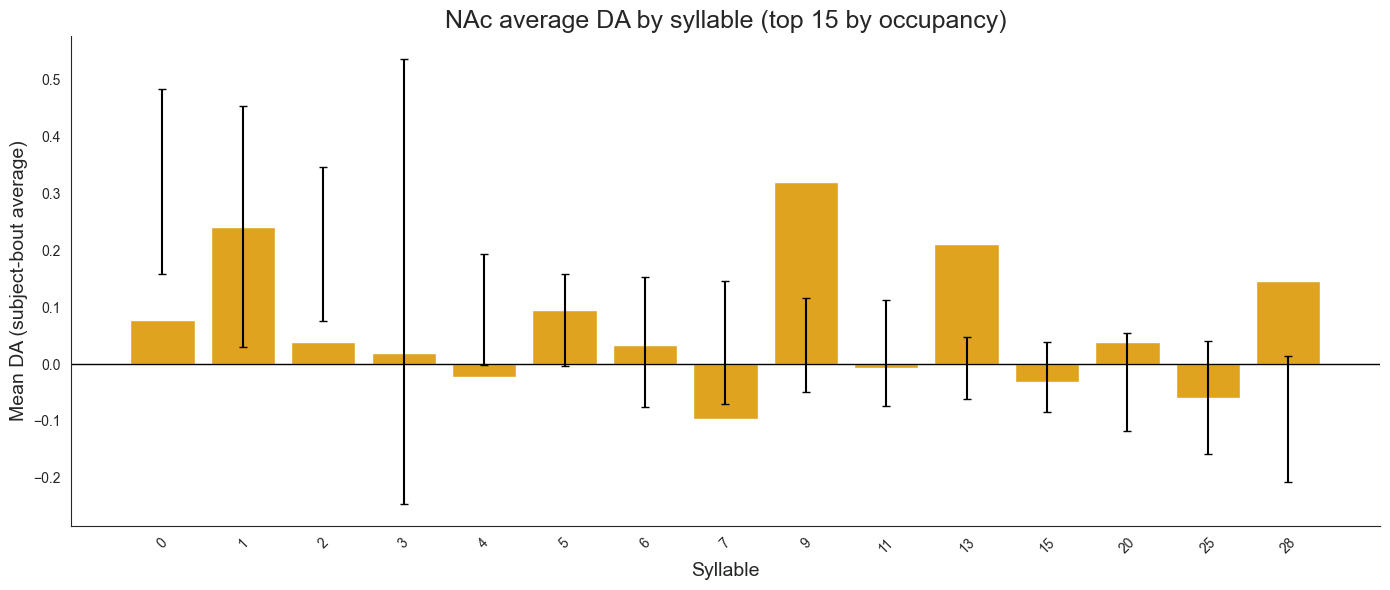

In [8]:
plot_df = syllable_subject_summary[syllable_subject_summary['syllable'].isin(top_syllables)].copy()
plot_df = plot_df.sort_values('mean_DA', ascending=False)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=plot_df, x='syllable', y='mean_DA', color='#FFAF00')

for bar, (_, row) in zip(ax.patches, plot_df.iterrows()):
    x = bar.get_x() + bar.get_width() / 2
    y = row['mean_DA']
    yerr = row['sem_DA']

    if pd.isna(y) or pd.isna(yerr):
        continue

    ax.errorbar(
        x=x,
        y=y,
        yerr=yerr,
        fmt='none',
        ecolor='black',
        capsize=3,
    )

ax.axhline(0, color='black', linewidth=1)
ax.set_title(f'NAc average DA by syllable (top {TOP_N_SYLLABLES} by occupancy)', fontsize=18)
ax.set_xlabel('Syllable', fontsize=14)
ax.set_ylabel('Mean DA (subject-bout average)', fontsize=14)
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()


C:\Users\alber\AppData\Local\Temp\ipykernel_29380\1807817335.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


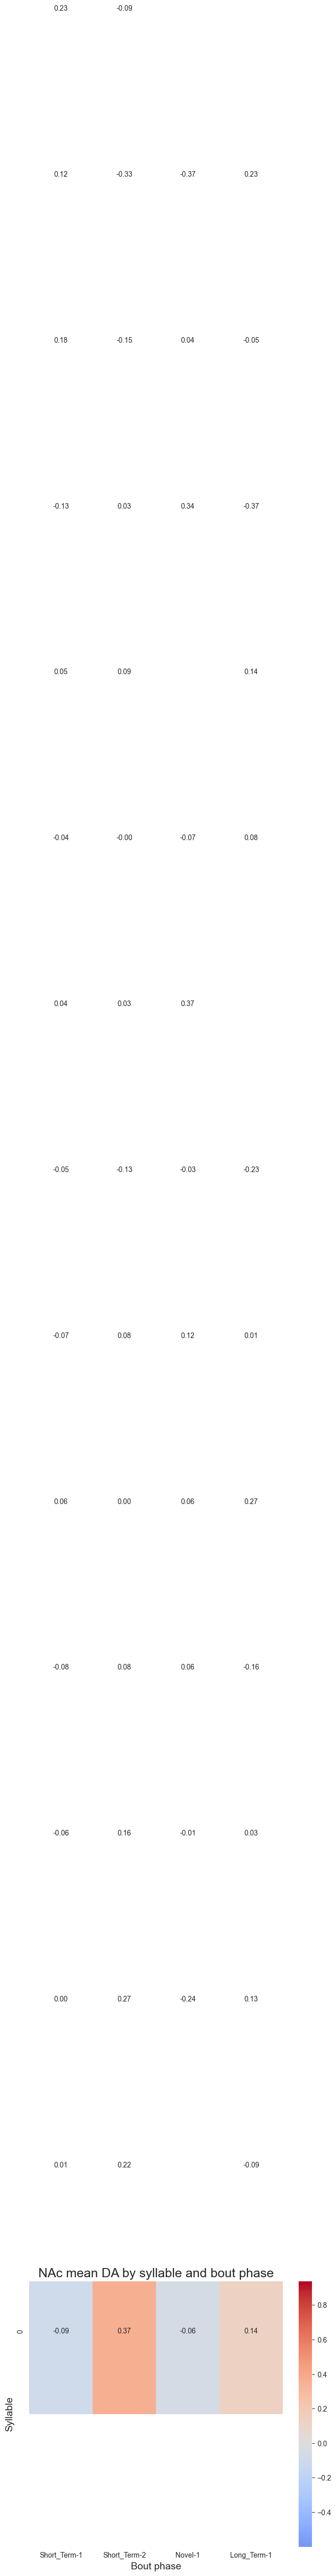

In [9]:
syllable_by_bout_summary = summarize_mean_da(subject_bout_syllable_means, ["bout_phase", "syllable"], value_col="mean_DA")
heatmap_df = (
    syllable_by_bout_summary[syllable_by_bout_summary["syllable"].isin(top_syllables)]
    .pivot(index="syllable", columns="bout_phase", values="mean_DA")
    .reindex(columns=BOUT_PHASE_ORDER)
)

plt.figure(figsize=(8, max(5, 0.45 * len(heatmap_df))))
sns.heatmap(heatmap_df, cmap=HEATMAP_CMAP, center=0, annot=True, fmt=".2f")
plt.title("NAc mean DA by syllable and bout phase", fontsize=18)
plt.xlabel("Bout phase", fontsize=14)
plt.ylabel("Syllable", fontsize=14)
if HEATMAP_YLIM is not None:
    plt.ylim(*HEATMAP_YLIM)
plt.tight_layout()
plt.show()

In [10]:
syllable_test_input = subject_bout_syllable_means[subject_bout_syllable_means["syllable"].isin(top_syllables)].copy()
syllable_group_summary, syllable_kruskal = kruskal_test_table(syllable_test_input, "syllable", value_col="mean_DA")
syllable_pairwise = pairwise_mwu(syllable_test_input, "syllable", value_col="mean_DA")

syllable_group_summary.sort_values("mean_DA", ascending=False).head(20), syllable_kruskal

(    syllable   n   mean_DA  median_DA
 8          9  41  0.320452   0.015561
 1          1  42  0.241119   0.002690
 10        13  42  0.210880   0.032537
 14        28   9  0.145714  -0.168132
 5          5  42  0.095078  -0.021858
 0          0  40  0.077082   0.001594
 2          2  34  0.038611  -0.074338
 12        20  32  0.037951  -0.177427
 6          6  41  0.033544  -0.081690
 3          3  36  0.019513  -0.086619
 9         11  41 -0.006924  -0.015728
 4          4  40 -0.022809  -0.100005
 11        15  34 -0.031096  -0.156269
 13        25  34 -0.058741  -0.138766
 7          7  34 -0.096569  -0.236822,
       test  statistic   p_value
 0  kruskal  22.059937  0.077391)

## Average DA by Bout Phase

In [11]:
subject_bout_means = (
    nac_df.groupby(["subject_name", "bout_phase"], as_index=False, observed=True)
    .agg(mean_DA=("zscore_DA", "mean"), n_frames=("zscore_DA", "size"))
)
bout_summary = summarize_mean_da(subject_bout_means, ["bout_phase"], value_col="mean_DA")
bout_summary["bout_phase"] = pd.Categorical(bout_summary["bout_phase"], categories=BOUT_PHASE_ORDER, ordered=True)
bout_summary = bout_summary.sort_values("bout_phase").reset_index(drop=True)
bout_summary

,bout_phase,n,mean_DA,median_DA,std_DA,sem_DA
0,Short_Term-1,11,0.017629,0.030792,0.072711,0.021923
1,Short_Term-2,11,-0.061416,-0.107045,0.503954,0.151948
2,Novel-1,11,0.171721,0.042592,0.435814,0.131403
3,Long_Term-1,11,0.133069,0.064301,0.283834,0.085579


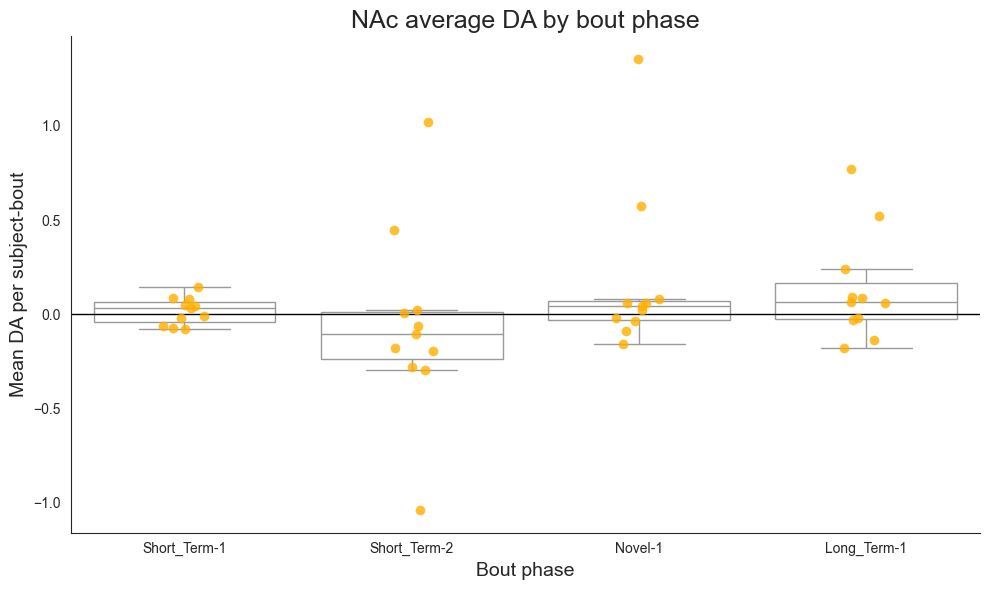

In [12]:
plot_df = subject_bout_means.copy()
plot_df["bout_phase"] = pd.Categorical(plot_df["bout_phase"], categories=BOUT_PHASE_ORDER, ordered=True)
plot_df = plot_df.sort_values("bout_phase")

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, x="bout_phase", y="mean_DA", color="white", fliersize=0)
sns.stripplot(data=plot_df, x="bout_phase", y="mean_DA", color="#FFAF00", size=7, alpha=0.8)
plt.axhline(0, color="black", linewidth=1)
plt.title("NAc average DA by bout phase", fontsize=18)
plt.xlabel("Bout phase", fontsize=14)
plt.ylabel("Mean DA per subject-bout", fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

In [13]:
bout_group_summary, bout_kruskal = kruskal_test_table(subject_bout_means, "bout_phase", value_col="mean_DA")
bout_pairwise = pairwise_mwu(subject_bout_means, "bout_phase", value_col="mean_DA")
bout_group_summary["bout_phase"] = pd.Categorical(bout_group_summary["bout_phase"], categories=BOUT_PHASE_ORDER, ordered=True)
bout_group_summary = bout_group_summary.sort_values("bout_phase")
bout_group_summary, bout_kruskal

(     bout_phase   n   mean_DA  median_DA
 0  Short_Term-1  11  0.017629   0.030792
 1  Short_Term-2  11 -0.061416  -0.107045
 2       Novel-1  11  0.171721   0.042592
 3   Long_Term-1  11  0.133069   0.064301,
       test  statistic   p_value
 0  kruskal   5.646832  0.130115)

## Export Tables

## Bout Window Sensitivity for Short_Term-1

This duplicates `Short_Term-1` into two additional versions:
- first 10 minutes
- first 5 minutes

That lets you compare the full bout against shorter windows.

In [14]:
nac_bout_window_df = add_short_term_windows(nac_df)
subject_bout_window_means = (
    nac_bout_window_df.groupby(["subject_name", "bout_phase_window"], as_index=False, observed=True)
    .agg(mean_DA=("zscore_DA", "mean"), n_frames=("zscore_DA", "size"))
)
bout_window_summary = summarize_mean_da(subject_bout_window_means, ["bout_phase_window"], value_col="mean_DA")
bout_window_summary = bout_window_summary.sort_values("bout_phase_window").reset_index(drop=True)
bout_window_summary

,bout_phase_window,n,mean_DA,median_DA,std_DA,sem_DA
0,Short_Term-1,11,0.017629,0.030792,0.072711,0.021923
1,Short_Term-1 (10 min),11,0.017770,0.028706,0.072415,0.021834
2,Short_Term-1 (5 min),11,0.048673,0.017683,0.182357,0.054983
3,Short_Term-2,11,-0.061416,-0.107045,0.503954,0.151948
4,Novel-1,11,0.171721,0.042592,0.435814,0.131403
5,Long_Term-1,11,0.133069,0.064301,0.283834,0.085579


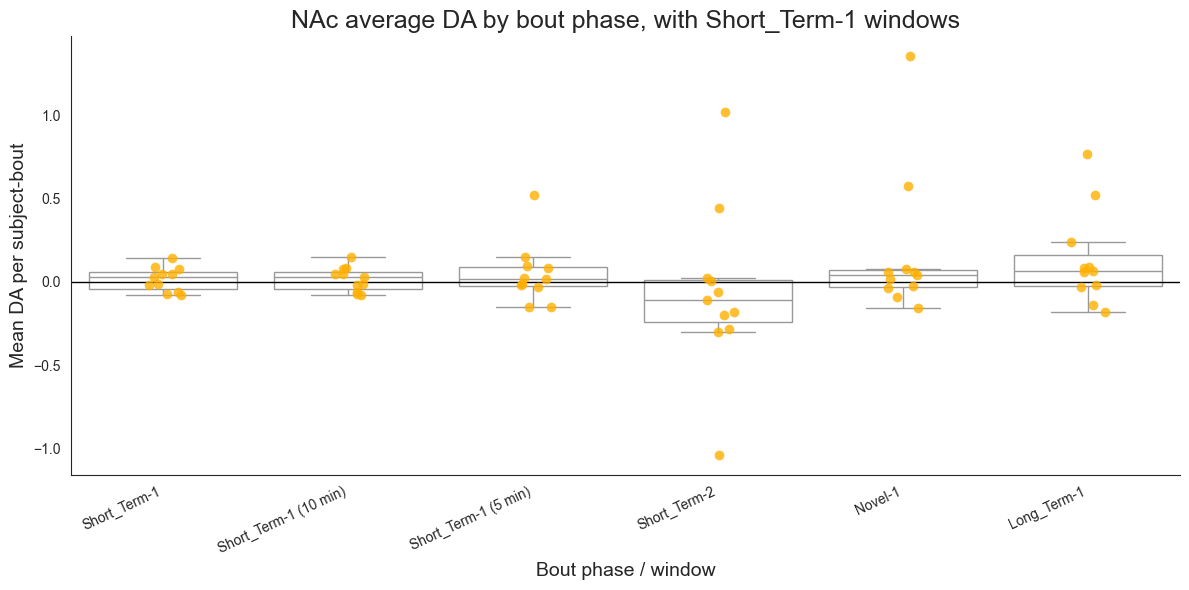

In [15]:
plot_df = subject_bout_window_means.sort_values("bout_phase_window").copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x="bout_phase_window", y="mean_DA", color="white", fliersize=0)
sns.stripplot(data=plot_df, x="bout_phase_window", y="mean_DA", color="#FFAF00", size=7, alpha=0.8)
plt.axhline(0, color="black", linewidth=1)
plt.title("NAc average DA by bout phase, with Short_Term-1 windows", fontsize=18)
plt.xlabel("Bout phase / window", fontsize=14)
plt.ylabel("Mean DA per subject-bout", fontsize=14)
plt.xticks(rotation=25, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

In [16]:
bout_window_group_summary, bout_window_kruskal = kruskal_test_table(subject_bout_window_means, "bout_phase_window", value_col="mean_DA")
bout_window_pairwise = pairwise_mwu(subject_bout_window_means, "bout_phase_window", value_col="mean_DA")
bout_window_group_summary = bout_window_group_summary.sort_values("bout_phase_window")
bout_window_group_summary, bout_window_kruskal

(       bout_phase_window   n   mean_DA  median_DA
 5            Long_Term-1  11  0.133069   0.064301
 4                Novel-1  11  0.171721   0.042592
 0           Short_Term-1  11  0.017629   0.030792
 1  Short_Term-1 (10 min)  11  0.017770   0.028706
 2   Short_Term-1 (5 min)  11  0.048673   0.017683
 3           Short_Term-2  11 -0.061416  -0.107045,
       test  statistic   p_value
 0  kruskal   6.002097  0.306015)

In [17]:
syllable_frame_summary.to_csv(OUTPUT_DIR / "nac_syllable_frame_summary.csv", index=False)
subject_bout_syllable_means.to_csv(OUTPUT_DIR / "nac_subject_bout_syllable_means.csv", index=False)
syllable_subject_summary.to_csv(OUTPUT_DIR / "nac_syllable_subject_summary.csv", index=False)
syllable_by_bout_summary.to_csv(OUTPUT_DIR / "nac_syllable_by_bout_summary.csv", index=False)
subject_bout_means.to_csv(OUTPUT_DIR / "nac_subject_bout_means.csv", index=False)
bout_summary.to_csv(OUTPUT_DIR / "nac_bout_summary.csv", index=False)
syllable_group_summary.to_csv(OUTPUT_DIR / "nac_syllable_kruskal_group_summary.csv", index=False)
syllable_kruskal.to_csv(OUTPUT_DIR / "nac_syllable_kruskal_test.csv", index=False)
syllable_pairwise.to_csv(OUTPUT_DIR / "nac_syllable_pairwise_mwu.csv", index=False)
bout_group_summary.to_csv(OUTPUT_DIR / "nac_bout_kruskal_group_summary.csv", index=False)
bout_kruskal.to_csv(OUTPUT_DIR / "nac_bout_kruskal_test.csv", index=False)
bout_pairwise.to_csv(OUTPUT_DIR / "nac_bout_pairwise_mwu.csv", index=False)
subject_bout_window_means.to_csv(OUTPUT_DIR / "nac_subject_bout_window_means.csv", index=False)
bout_window_summary.to_csv(OUTPUT_DIR / "nac_bout_window_summary.csv", index=False)
bout_window_group_summary.to_csv(OUTPUT_DIR / "nac_bout_window_kruskal_group_summary.csv", index=False)
bout_window_kruskal.to_csv(OUTPUT_DIR / "nac_bout_window_kruskal_test.csv", index=False)
bout_window_pairwise.to_csv(OUTPUT_DIR / "nac_bout_window_pairwise_mwu.csv", index=False)
print(f"Saved outputs to: {OUTPUT_DIR}")

Saved outputs to: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\nac_syllable_da_summary_outputs
